In [1]:
# =========================
# 1) Install
# =========================
!pip -q install -U timm google-genai

# =========================
# 2) Imports
# =========================
import os
import re
import mimetypes
import getpass

import torch
import timm
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from google import genai
from google.genai import types
from google.colab import files

# =========================
# 3) User-editable defaults
# IMPORTANT:
# - If your final_model_v1.pth was trained with a different backbone,
#   change DEFAULT_VISION_MODEL_NAME.
# - CLASS ORDER MUST MATCH TRAINING ORDER EXACTLY.
# =========================
DEFAULT_VISION_MODEL_NAME = "swin_small_patch4_window7_224"
DEFAULT_IMG_SIZE = 224

DEFAULT_CLASS_NAMES = sorted([
    "Acne and Rosacea Photos",
    "Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions",
    "Atopic Dermatitis Photos",
    "Bullous Disease Photos",
    "Cellulitis Impetigo and other Bacterial Infections",
    "Eczema Photos",
    "Exanthems and Drug Eruptions",
    "Hair Loss Photos Alopecia and other Hair Diseases",
    "Herpes HPV and other STDs Photos",
    "Light Diseases and Disorders of Pigmentation",
    "Lupus and other Connective Tissue diseases",
    "Melanoma Skin Cancer Nevi and Moles",
    "Nail Fungus and other Nail Disease",
    "Poison Ivy Photos and other Contact Dermatitis",
    "Psoriasis pictures Lichen Planus and related diseases",
    "Scabies Lyme Disease and other Infestations and Bites",
    "Seborrheic Keratoses and other Benign Tumors",
    "Systemic Disease",
    "Tinea Ringworm Candidiasis and other Fungal Infections",
    "Urticaria Hives",
    "Vascular Tumors",
    "Vasculitis Photos",
    "Warts Molluscum and other Viral Infections",
])

# Gemini settings
GEMINI_MODEL_NAME = "gemini-2.5-flash"
THINKING_BUDGET = 0
MAX_OUTPUT_TOKENS = 220
TEMPERATURE = 0.1

TOP_K = 3
SHOW_IMAGE = True

# =========================
# 4) Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 5) Gemini API key
# =========================
api_key = getpass.getpass("Enter GEMINI_API_KEY: ").strip()
client = genai.Client(api_key=api_key)

# =========================
# 6) Upload MODEL + IMAGE together
# =========================
print("\nPlease upload your MODEL file (.pth/.pt) and ONE image together.")
uploaded = files.upload()

model_path = None
image_path = None

for filename in uploaded.keys():
    lower = filename.lower()
    if lower.endswith((".pth", ".pt")):
        model_path = filename
    elif lower.endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
        image_path = filename

if not model_path:
    raise FileNotFoundError("No .pth or .pt model file was uploaded.")
if not image_path:
    raise FileNotFoundError("No image file was uploaded.")

print(f"\nModel file: {model_path}")
print(f"Image file: {image_path}")

# =========================
# 7) Helper functions for model loading
# =========================
def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")
    except Exception:
        return torch.load(path, map_location="cpu")

def normalize_state_dict(state_dict):
    cleaned = {}
    for k, v in state_dict.items():
        new_k = k
        for prefix in ("module.", "model."):
            if new_k.startswith(prefix):
                new_k = new_k[len(prefix):]
        cleaned[new_k] = v
    return cleaned

def infer_num_classes_from_state_dict(state_dict):
    candidate_keys = [
        "head.weight",
        "classifier.weight",
        "fc.weight",
        "head.fc.weight",
    ]
    for key in candidate_keys:
        if key in state_dict and hasattr(state_dict[key], "shape") and len(state_dict[key].shape) == 2:
            return int(state_dict[key].shape[0])
    return None

def extract_checkpoint_data(checkpoint):
    meta = {
        "model_name": DEFAULT_VISION_MODEL_NAME,
        "img_size": DEFAULT_IMG_SIZE,
        "class_names": DEFAULT_CLASS_NAMES,
    }

    state_dict = None

    if isinstance(checkpoint, torch.nn.Module):
        state_dict = checkpoint.state_dict()

    elif isinstance(checkpoint, dict):
        # metadata if present
        for key in ["model_name", "arch", "architecture", "backbone", "encoder_name", "net_name"]:
            if isinstance(checkpoint.get(key), str):
                meta["model_name"] = checkpoint[key]
                break

        for key in ["img_size", "image_size", "input_size", "resolution"]:
            value = checkpoint.get(key)
            if isinstance(value, int):
                meta["img_size"] = value
                break
            if isinstance(value, (list, tuple)) and len(value) >= 1 and isinstance(value[0], int):
                meta["img_size"] = int(value[0])
                break

        for key in ["class_names", "classes", "labels"]:
            value = checkpoint.get(key)
            if isinstance(value, (list, tuple)) and len(value) > 1:
                meta["class_names"] = list(value)
                break

        # state dict candidates
        for key in ["state_dict", "model_state_dict", "model", "net", "weights"]:
            value = checkpoint.get(key)
            if isinstance(value, dict):
                state_dict = value
                break

        # raw state_dict directly
        if state_dict is None:
            tensor_like_values = 0
            total_values = 0
            for v in checkpoint.values():
                total_values += 1
                if torch.is_tensor(v):
                    tensor_like_values += 1
            if total_values > 0 and tensor_like_values == total_values:
                state_dict = checkpoint

    else:
        state_dict = checkpoint

    if state_dict is None:
        raise ValueError(
            "Could not extract a state_dict from the checkpoint. "
            "If your .pth stores a full custom model object, you may need the original model class code."
        )

    state_dict = normalize_state_dict(state_dict)

    inferred_num_classes = infer_num_classes_from_state_dict(state_dict)
    if inferred_num_classes is not None and len(meta["class_names"]) != inferred_num_classes:
        if inferred_num_classes == len(DEFAULT_CLASS_NAMES):
            meta["class_names"] = DEFAULT_CLASS_NAMES
        else:
            print(
                f"WARNING: checkpoint suggests {inferred_num_classes} classes, "
                f"but class_names has {len(meta['class_names'])}. Using generic class names."
            )
            meta["class_names"] = [f"Class {i}" for i in range(inferred_num_classes)]

    return state_dict, meta

def load_model(path):
    checkpoint = safe_torch_load(path)
    state_dict, meta = extract_checkpoint_data(checkpoint)

    model_name = meta["model_name"]
    class_names = meta["class_names"]
    img_size = meta["img_size"]

    print("\nResolved model config:")
    print(" backbone :", model_name)
    print(" img_size :", img_size)
    print(" classes  :", len(class_names))

    model = timm.create_model(
        model_name,
        pretrained=False,
        num_classes=len(class_names),
    )

    load_result = model.load_state_dict(state_dict, strict=False)
    print("\nCheckpoint load report:")
    print(" missing keys   :", len(load_result.missing_keys))
    print(" unexpected keys:", len(load_result.unexpected_keys))

    if len(load_result.missing_keys) > 0:
        print(" first missing keys   :", load_result.missing_keys[:5])
    if len(load_result.unexpected_keys) > 0:
        print(" first unexpected keys:", load_result.unexpected_keys[:5])

    model.to(device).eval()
    return model, class_names, img_size

# =========================
# 8) Image preprocessing + top-k prediction
# =========================
def build_preprocess(img_size):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

def predict_topk(model, pil_img, class_names, img_size, top_k=3):
    preprocess = build_preprocess(img_size)
    input_tensor = preprocess(pil_img).unsqueeze(0).to(device)

    with torch.inference_mode():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]

    k = min(top_k, len(class_names))
    top_probs, top_indices = torch.topk(probs, k=k)

    results = []
    for rank, (idx, prob) in enumerate(zip(top_indices.tolist(), top_probs.tolist()), start=1):
        class_name = class_names[idx] if idx < len(class_names) else f"Class {idx}"
        results.append({
            "rank": rank,
            "class_index": idx,
            "class_name": class_name,
            "confidence": prob * 100.0,
        })
    return results

def format_classifier_summary(predictions):
    lines = []
    for item in predictions:
        lines.append(f"{item['rank']}. {item['class_name']} ({item['confidence']:.2f}%)")
    return "\n".join(lines)

# =========================
# 9) Sample psoriasis-like patient data
# Adjust freely for your test
# =========================
PATIENT_DATA = {
    "gender": "male",
    "age": 32,
    "height_cm": 178,
    "weight_kg": 80,
    "skin_type": "normal",
    "allergies": [],
    "past_medical_history": [
        "seasonal allergic rhinitis"
    ],
    "diabetes": "no",
    "current_medications": [
        "fragrance-free moisturizer occasionally"
    ],
    "chief_complaint": [
        "I have thick red scaly patches on both elbows and knees.",
        "They have been flaring on and off for about 4 months.",
        "The areas itch and sometimes crack and sting.",
        "There is white flaky scale on top of the plaques.",
        "I also notice some scaling near the scalp line.",
        "It seems worse during stress and in cold weather."
    ],
    "location_on_body": [
        "both elbows",
        "both knees",
        "scalp near the hairline"
    ],
    "duration": "about 4 months",
    "symptoms": [
        "itching",
        "thick plaques",
        "dry scaling",
        "flaking",
        "occasional cracking",
        "mild soreness"
    ],
    "triggers": [
        "stress",
        "cold weather",
        "skin irritation"
    ]
}

# =========================
# 10) Patient text builder
# =========================
def build_patient_info_text(patient_data: dict) -> str:
    def format_value(value):
        if isinstance(value, list):
            return ", ".join(str(v) for v in value)
        return str(value)

    ordered_keys = [
        "gender",
        "age",
        "height_cm",
        "weight_kg",
        "skin_type",
        "allergies",
        "past_medical_history",
        "diabetes",
        "current_medications",
        "chief_complaint",
        "location_on_body",
        "duration",
        "symptoms",
        "triggers",
    ]

    lines = []
    for key in ordered_keys:
        if key in patient_data and patient_data[key] not in [None, "", [], {}]:
            value = patient_data[key]
            if isinstance(value, list):
                if key in ["chief_complaint", "location_on_body"]:
                    lines.append(f"{key}:")
                    for item in value:
                        lines.append(f"- {item}")
                else:
                    lines.append(f"{key}: {format_value(value)}")
            else:
                lines.append(f"{key}: {format_value(value)}")

    return "\n".join(lines).strip()

# =========================
# 11) Gemini system instruction
# Paragraph 1 = your usual answer style
# Paragraph 2 = brief model-agreement note
# =========================
SYSTEM_INSTRUCTION = """
You are a conservative dermatology assistant used for doctor support.

Return ONLY plain English text.
Do NOT return JSON.
Do NOT return markdown.
Do NOT return bullet points.
Do NOT use headings.
Do NOT mention hidden reasoning.
Do NOT mention chain-of-thought.
Do NOT mention probabilities in the final answer.
Do NOT mention that you corrected or summarized the complaint.

Before answering, silently do all of the following:
1) Correct obvious spelling mistakes in the patient's complaint.
2) Normalize and summarize the complaint into a short internal clinical impression.
3) Determine whether the uploaded image is actually relevant to dermatology.

Image relevance rules:
- If the uploaded content is not a dermatology-relevant skin image, return exactly:
  The most likely condition is undetected. The uploaded content does not appear to be a relevant dermatology image.
- Examples of irrelevant content include x-rays, CT scans, MRI scans, screenshots, documents, math problems, charts, random objects, or non-skin photos with no visible skin lesion.
- If the image is too blurry, too dark, too cropped, too distant, or otherwise not reliable for skin assessment, return exactly:
  The most likely condition is undetected. The image quality is not sufficient for a reliable dermatology assessment.

Diagnostic rules:
- Use the image as the primary evidence.
- Use patient metadata only as secondary supporting context.
- Use the external classifier output only as tertiary supporting context.
- Do not blindly trust the classifier.
- Do not invent visual findings.
- Do not rely mainly on past medical history.
- Past medical history may support recurrence only if the current image and present symptoms are also compatible with that condition.
- Ignore unrelated past conditions if they do not fit the current image and complaint.
- If the image clearly shows normal skin with no meaningful abnormality, you may say:
  The most likely condition is healthy skin.
- If the case is skin-related but too ambiguous for one reliable label, say:
  The most likely condition is undetermined.

Output format rules:
- If the image is irrelevant or too poor quality, return only the exact undetected response and nothing else.
- Otherwise return exactly 2 short paragraphs.
- Paragraph 1 must be 3 to 5 short sentences only.
- Paragraph 2 must be 1 to 2 short sentences only.
- Paragraph 1 sentence 1 must start exactly with:
  The most likely condition is ...
- Paragraph 1 should use a broad umbrella diagnosis when appropriate, such as eczema, acne, fungal skin infection, psoriasis, or burn injury.
- Paragraph 1 sentence 2 should, if reasonably supported by the image and history, provide a more specific clinical detail or subtype that may help the doctor.
- Paragraph 1 sentence 3 must briefly explain the main reasons using visible findings and symptom history.
- Paragraph 1 sentence 4 is optional and may mention whether past medical history supports recurrence or clinical context.
- Paragraph 1 sentence 5 is optional and may contain brief low-risk practical advice.
- Paragraph 2 must briefly comment on whether the classifier output agrees or disagrees with the image-focused assessment.
- Paragraph 2 may mention classifier class labels, but should stay concise.
- Do not use headings like "Reasoning" or "Model output".

Specificity rules:
- Prefer a broad umbrella label first, because the same output may also be shown to the patient.
- Add a more specific subtype only if it is reasonably supported by the current image and current complaint.
- Example:
  The most likely condition is eczema. More specifically, this appears most consistent with contact dermatitis.
- Do not force a subtype if the subtype is uncertain.

Advice rules:
- Only include low-risk, general advice.
- Avoid herbal, botanical, essential-oil, or natural remedy recommendations.
- Do not prescribe drugs or doses.
- Safe advice may include avoiding triggers, reducing irritant exposure, using a gentle fragrance-free moisturizer, and seeking dermatology review if persistent or worsening.
""".strip()

# =========================
# 12) Gemini user prompt builder
# =========================
def build_prompt(patient_info_text: str, classifier_summary: str) -> str:
    return f"""
Review ONE uploaded image together with the patient information and the external dermatology classifier output below.

Task:
- Identify the single most likely skin condition.
- Use the image as the main evidence and the patient information as supporting context.
- Treat the external classifier output as secondary support only; do not follow it blindly.
- If the upload is irrelevant to dermatology, return the exact undetected response.
- If the image is dermatology-related but still too uncertain for one reliable diagnosis, say:
  The most likely condition is undetermined.
- Start with a broad umbrella diagnosis that is easier for a patient to understand.
- Then, if supported, add a more specific clinical subtype or detail that may help the doctor.
- If a past condition is relevant and consistent with the current image and symptoms, you may mention that it could support recurrence or clinical context.
- Do not focus only on history; the current image must remain primary.
- After the main diagnostic paragraph, add a second short paragraph that briefly states whether the classifier output seems to agree or disagree with your image-focused assessment, and why.


Classifier accuracy is %74.5, so be careful about result.
External dermatology classifier top predictions:
{classifier_summary}

Preferred style example:
The most likely condition is eczema. More specifically, this appears most consistent with contact dermatitis of the hands. This is suggested by redness, dryness, scaling, fissures, and worsening after frequent washing and detergent exposure. Advice: reduce irritant exposure, use a gentle fragrance-free moisturizer, and seek dermatology review if the rash persists or worsens.

The classifier output is reasonably consistent because eczema-related irritation fits better than unrelated alternatives.

Patient information:
{patient_info_text}
""".strip()

# =========================
# 13) Response cleaner
# =========================
UNDETECTED_IRRELEVANT = (
    "The most likely condition is undetected. "
    "The uploaded content does not appear to be a relevant dermatology image."
)

UNDETECTED_QUALITY = (
    "The most likely condition is undetected. "
    "The image quality is not sufficient for a reliable dermatology assessment."
)

def _limit_sentences(text, max_sentences):
    text = re.sub(r"\s+", " ", text).strip()
    parts = re.split(r'(?<=[.!?])\s+', text)
    parts = [p.strip() for p in parts if p.strip()]
    return " ".join(parts[:max_sentences]).strip()

def clean_response(text: str) -> str:
    if not text:
        return UNDETECTED_QUALITY

    s = text.strip()

    # remove accidental code fences
    s = re.sub(r"^```[a-zA-Z0-9_-]*\n?", "", s)
    s = re.sub(r"```$", "", s).strip()

    s = s.strip()
    if s == UNDETECTED_IRRELEVANT or s == UNDETECTED_QUALITY:
        return s

    # split into paragraphs if present
    paragraphs = [p.strip() for p in re.split(r"\n\s*\n", s) if p.strip()]

    if len(paragraphs) == 0:
        return UNDETECTED_QUALITY

    p1 = _limit_sentences(paragraphs[0], 5)
    if not p1.lower().startswith("the most likely condition is"):
        p1 = "The most likely condition is undetermined. " + p1

    if len(paragraphs) >= 2:
        p2 = _limit_sentences(paragraphs[1], 2)
        if len(p2) > 0:
            return p1 + "\n\n" + p2

    return p1

# =========================
# 14) Main combined inference
# =========================
def analyze_dermatology_case_with_classifier(
    image_bytes: bytes,
    mime_type: str,
    patient_data: dict,
    classifier_predictions: list,
    model_name: str = GEMINI_MODEL_NAME,
    thinking_budget: int = THINKING_BUDGET,
    max_output_tokens: int = MAX_OUTPUT_TOKENS,
    temperature: float = TEMPERATURE,
) -> str:
    patient_info_text = build_patient_info_text(patient_data)
    classifier_summary = format_classifier_summary(classifier_predictions)
    prompt = build_prompt(patient_info_text, classifier_summary)

    image_part = types.Part.from_bytes(
        data=image_bytes,
        mime_type=mime_type
    )

    response = client.models.generate_content(
        model=model_name,
        contents=[image_part, prompt],
        config=types.GenerateContentConfig(
            system_instruction=SYSTEM_INSTRUCTION,
            temperature=temperature,
            max_output_tokens=max_output_tokens,
            thinking_config=types.ThinkingConfig(
                thinking_budget=thinking_budget
            )
        )
    )

    return clean_response(response.text)





     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 760.6/760.6 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.1 which is incompatible.
Device: cpu
Enter GEMINI_API_KEY: ··········

Please upload your MODEL file (.pth/.pt) and ONE image together.


Saving final_model_v1.pth to final_model_v1.pth
Saving sedef.jpg to sedef.jpg

Model file: final_model_v1.pth
Image file: sedef.jpg



Resolved model config:
 backbone : swin_small_patch4_window7_224
 img_size : 224
 classes  : 23

Checkpoint load report:
 missing keys   : 0
 unexpected keys: 0

=== CLASSIFIER TOP-3 ===
1. Psoriasis pictures Lichen Planus and related diseases (97.24%)
2. Vasculitis Photos (0.60%)
3. Nail Fungus and other Nail Disease (0.37%)


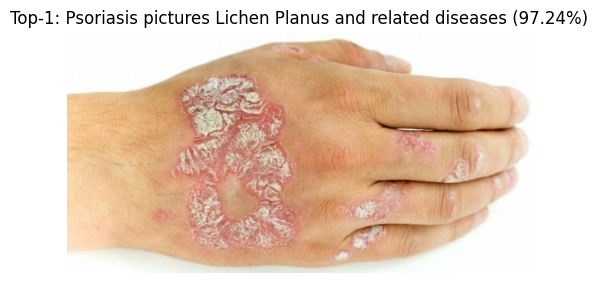

In [2]:
# =========================
# 15) Run everything
# =========================
# Load image bytes for Gemini
mime_type = mimetypes.guess_type(image_path)[0] or "image/jpeg"
with open(image_path, "rb") as f:
    image_bytes = f.read()

# Load PIL image
pil_img = Image.open(image_path).convert("RGB")

# Load classifier
model, class_names, img_size = load_model(model_path)

# Predict top-3
classifier_predictions = predict_topk(
    model=model,
    pil_img=pil_img,
    class_names=class_names,
    img_size=img_size,
    top_k=TOP_K
)

# Print classifier outputs
print("\n=== CLASSIFIER TOP-3 ===")
for item in classifier_predictions:
    print(f"{item['rank']}. {item['class_name']} ({item['confidence']:.2f}%)")

# Optional image preview
if SHOW_IMAGE:
    plt.figure(figsize=(6, 6))
    plt.imshow(pil_img)
    plt.axis("off")
    plt.title(
        f"Top-1: {classifier_predictions[0]['class_name']} "
        f"({classifier_predictions[0]['confidence']:.2f}%)"
    )
    plt.show()

In [3]:
# Gemini combined response
final_response = analyze_dermatology_case_with_classifier(
    image_bytes=image_bytes,
    mime_type=mime_type,
    patient_data=PATIENT_DATA,
    classifier_predictions=classifier_predictions
)

print("\n=== GEMINI COMBINED RESPONSE ===")
print(final_response)


=== GEMINI COMBINED RESPONSE ===
The most likely condition is psoriasis. This is suggested by the well-demarcated red plaques with thick, silvery-white scales visible on the hand, which are characteristic findings. The patient's history of similar patches on elbows, knees, and scalp, along with itching, cracking, and flaring with stress and cold weather, further supports this diagnosis. Using a fragrance-free moisturizer may help with dryness.

The classifier output is consistent with this assessment, with "Psoriasis pictures Lichen Planus and related diseases" as the top prediction.


In [7]:
final_response

'The most likely condition is psoriasis. This is suggested by the well-demarcated red plaques with thick, silvery-white scales visible on the hand, which are characteristic findings. The patient\'s history of similar patches on elbows, knees, and scalp, along with itching, cracking, and flaring with stress and cold weather, further supports this diagnosis. Using a fragrance-free moisturizer may help with dryness.\n\nThe classifier output is consistent with this assessment, with "Psoriasis pictures Lichen Planus and related diseases" as the top prediction.'

# acne vulgaris

Device: cpu
Enter GEMINI_API_KEY: ··········
Model path: /content/final_model_v1.pth

Please upload ONE image file.


Saving WhatsApp Image 2026-04-01 at 13.13.09.jpeg to WhatsApp Image 2026-04-01 at 13.13.09.jpeg
Image file: WhatsApp Image 2026-04-01 at 13.13.09.jpeg

Resolved model config:
 backbone : swin_small_patch4_window7_224
 img_size : 224
 classes  : 23

Checkpoint load report:
 missing keys   : 0
 unexpected keys: 0

=== CLASSIFIER TOP-3 ===
1. Hair Loss Photos Alopecia and other Hair Diseases (21.93%)
2. Acne and Rosacea Photos (14.97%)
3. Vascular Tumors (12.41%)


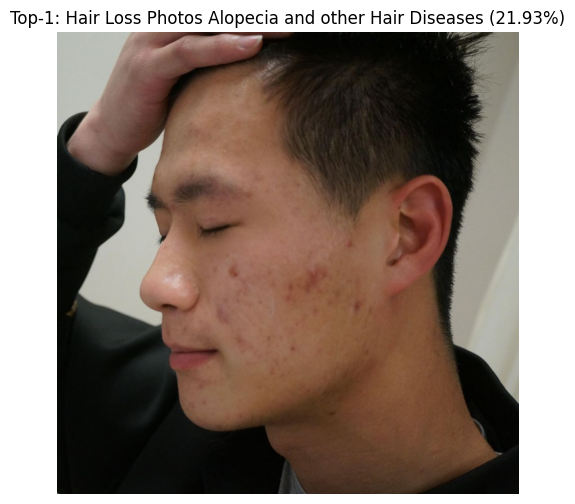


=== GEMINI COMBINED RESPONSE ===
The most likely condition is acne. More specifically, this appears most consistent with acne vulgaris. This is suggested by the presence of multiple erythematous papules, some with central whiteheads, and post-inflammatory hyperpigmentation on the cheeks and forehead. The patient's history of oily skin, recurrent breakouts, and worsening over recent months further supports this diagnosis.

The classifier output is reasonably consistent, as acne and rosacea photos were among the top predictions, which aligns with the clinical presentation of acne.


In [10]:
# =========================
# 1) Install
# =========================
!pip -q install -U timm google-genai

# =========================
# 2) Imports
# =========================
import os
import re
import mimetypes
import getpass

import torch
import timm
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from google import genai
from google.genai import types
from google.colab import files

# =========================
# 3) Config
# =========================
# If your model file is already in Colab, keep this filename.
# If needed, change only this line.
MODEL_FILENAME = "final_model_v1.pth"

# Fallback defaults in case checkpoint does not store metadata
DEFAULT_VISION_MODEL_NAME = "swin_small_patch4_window7_224"
DEFAULT_IMG_SIZE = 224

DEFAULT_CLASS_NAMES = sorted([
    "Acne and Rosacea Photos",
    "Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions",
    "Atopic Dermatitis Photos",
    "Bullous Disease Photos",
    "Cellulitis Impetigo and other Bacterial Infections",
    "Eczema Photos",
    "Exanthems and Drug Eruptions",
    "Hair Loss Photos Alopecia and other Hair Diseases",
    "Herpes HPV and other STDs Photos",
    "Light Diseases and Disorders of Pigmentation",
    "Lupus and other Connective Tissue diseases",
    "Melanoma Skin Cancer Nevi and Moles",
    "Nail Fungus and other Nail Disease",
    "Poison Ivy Photos and other Contact Dermatitis",
    "Psoriasis pictures Lichen Planus and related diseases",
    "Scabies Lyme Disease and other Infestations and Bites",
    "Seborrheic Keratoses and other Benign Tumors",
    "Systemic Disease",
    "Tinea Ringworm Candidiasis and other Fungal Infections",
    "Urticaria Hives",
    "Vascular Tumors",
    "Vasculitis Photos",
    "Warts Molluscum and other Viral Infections",
])

GEMINI_MODEL_NAME = "gemini-2.5-flash"
THINKING_BUDGET = 0
MAX_OUTPUT_TOKENS = 230
TEMPERATURE = 0.1
TOP_K = 3
SHOW_IMAGE = True

# =========================
# 4) Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 5) Gemini API key
# =========================
api_key = getpass.getpass("Enter GEMINI_API_KEY: ").strip()
client = genai.Client(api_key=api_key)

# =========================
# 6) Find model path in Colab
# =========================
def find_model_file(filename: str):
    # common exact location
    direct_path = os.path.join("/content", filename)
    if os.path.exists(direct_path):
        return direct_path

    # recursive search
    for root, _, files_in_dir in os.walk("/content"):
        if filename in files_in_dir:
            return os.path.join(root, filename)

    raise FileNotFoundError(
        f"Model file '{filename}' was not found under /content. "
        f"Please check the file name."
    )

MODEL_PATH = find_model_file(MODEL_FILENAME)
print("Model path:", MODEL_PATH)

# =========================
# 7) Upload ONLY image
# =========================
print("\nPlease upload ONE image file.")
uploaded = files.upload()

image_path = None
for filename in uploaded.keys():
    lower = filename.lower()
    if lower.endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
        image_path = filename
        break

if not image_path:
    raise FileNotFoundError("No valid image file was uploaded.")

print("Image file:", image_path)

# =========================
# 8) Helper functions for checkpoint loading
# =========================
def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")
    except Exception:
        return torch.load(path, map_location="cpu")

def normalize_state_dict(state_dict):
    cleaned = {}
    for k, v in state_dict.items():
        new_k = k
        for prefix in ("module.", "model."):
            if new_k.startswith(prefix):
                new_k = new_k[len(prefix):]
        cleaned[new_k] = v
    return cleaned

def infer_num_classes_from_state_dict(state_dict):
    candidate_keys = [
        "head.weight",
        "classifier.weight",
        "fc.weight",
        "head.fc.weight",
    ]
    for key in candidate_keys:
        if key in state_dict and hasattr(state_dict[key], "shape") and len(state_dict[key].shape) == 2:
            return int(state_dict[key].shape[0])
    return None

def extract_checkpoint_data(checkpoint):
    meta = {
        "model_name": DEFAULT_VISION_MODEL_NAME,
        "img_size": DEFAULT_IMG_SIZE,
        "class_names": DEFAULT_CLASS_NAMES,
    }

    state_dict = None

    if isinstance(checkpoint, torch.nn.Module):
        state_dict = checkpoint.state_dict()

    elif isinstance(checkpoint, dict):
        for key in ["model_name", "arch", "architecture", "backbone", "encoder_name", "net_name"]:
            if isinstance(checkpoint.get(key), str):
                meta["model_name"] = checkpoint[key]
                break

        for key in ["img_size", "image_size", "input_size", "resolution"]:
            value = checkpoint.get(key)
            if isinstance(value, int):
                meta["img_size"] = value
                break
            if isinstance(value, (list, tuple)) and len(value) >= 1 and isinstance(value[0], int):
                meta["img_size"] = int(value[0])
                break

        for key in ["class_names", "classes", "labels"]:
            value = checkpoint.get(key)
            if isinstance(value, (list, tuple)) and len(value) > 1:
                meta["class_names"] = list(value)
                break

        for key in ["state_dict", "model_state_dict", "model", "net", "weights"]:
            value = checkpoint.get(key)
            if isinstance(value, dict):
                state_dict = value
                break

        if state_dict is None:
            tensor_like_values = 0
            total_values = 0
            for v in checkpoint.values():
                total_values += 1
                if torch.is_tensor(v):
                    tensor_like_values += 1
            if total_values > 0 and tensor_like_values == total_values:
                state_dict = checkpoint

    else:
        state_dict = checkpoint

    if state_dict is None:
        raise ValueError(
            "Could not extract a state_dict from the checkpoint. "
            "If your .pth stores a full custom model object, original model class code may be needed."
        )

    state_dict = normalize_state_dict(state_dict)

    inferred_num_classes = infer_num_classes_from_state_dict(state_dict)
    if inferred_num_classes is not None and len(meta["class_names"]) != inferred_num_classes:
        if inferred_num_classes == len(DEFAULT_CLASS_NAMES):
            meta["class_names"] = DEFAULT_CLASS_NAMES
        else:
            print(
                f"WARNING: checkpoint suggests {inferred_num_classes} classes "
                f"but class_names has {len(meta['class_names'])}. Using generic class names."
            )
            meta["class_names"] = [f"Class {i}" for i in range(inferred_num_classes)]

    return state_dict, meta

def load_model(path):
    checkpoint = safe_torch_load(path)
    state_dict, meta = extract_checkpoint_data(checkpoint)

    model_name = meta["model_name"]
    class_names = meta["class_names"]
    img_size = meta["img_size"]

    print("\nResolved model config:")
    print(" backbone :", model_name)
    print(" img_size :", img_size)
    print(" classes  :", len(class_names))

    model = timm.create_model(
        model_name,
        pretrained=False,
        num_classes=len(class_names),
    )

    load_result = model.load_state_dict(state_dict, strict=False)

    print("\nCheckpoint load report:")
    print(" missing keys   :", len(load_result.missing_keys))
    print(" unexpected keys:", len(load_result.unexpected_keys))
    if len(load_result.missing_keys) > 0:
        print(" first missing keys   :", load_result.missing_keys[:5])
    if len(load_result.unexpected_keys) > 0:
        print(" first unexpected keys:", load_result.unexpected_keys[:5])

    model.to(device).eval()
    return model, class_names, img_size

# =========================
# 9) Preprocess + prediction
# =========================
def build_preprocess(img_size):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

def predict_topk(model, pil_img, class_names, img_size, top_k=3):
    preprocess = build_preprocess(img_size)
    input_tensor = preprocess(pil_img).unsqueeze(0).to(device)

    with torch.inference_mode():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]

    k = min(top_k, len(class_names))
    top_probs, top_indices = torch.topk(probs, k=k)

    results = []
    for rank, (idx, prob) in enumerate(zip(top_indices.tolist(), top_probs.tolist()), start=1):
        class_name = class_names[idx] if idx < len(class_names) else f"Class {idx}"
        results.append({
            "rank": rank,
            "class_index": idx,
            "class_name": class_name,
            "confidence": prob * 100.0,
        })
    return results

def format_classifier_summary(predictions):
    lines = []
    for item in predictions:
        lines.append(f"{item['rank']}. {item['class_name']} ({item['confidence']:.2f}%)")
    return "\n".join(lines)

# =========================
# 10) Acne vulgaris patient data
# =========================
PATIENT_DATA = {
    "gender": "male",
    "age": 24,
    "height_cm": 178,
    "weight_kg": 76,
    "skin_type": "oily",
    "allergies": [],
    "past_medical_history": [
        "mild adolescent acne"
    ],
    "diabetes": "no",
    "current_medications": [],
    "chief_complaint": [
        "I have pimples on my face, mostly on my cheeks and forehead.",
        "I also get some on my chin and jawline.",
        "There are red bumps and a few whiteheads, and sometimes the spots feel tender.",
        "My skin looks oily and I keep getting new breakouts.",
        "The acne has been getting worse over the last 2 to 3 months.",
        "I sometimes pick at the lesions and a few marks stay after they heal."
    ],
    "location_on_body": [
        "face",
        "cheeks",
        "forehead",
        "chin",
        "jawline"
    ],
    "duration": "about 2 to 3 months",
    "symptoms": [
        "facial breakouts",
        "whiteheads",
        "red bumps",
        "occasional tender pimples",
        "oily skin",
        "post-acne marks"
    ],
    "triggers": [
        "stress",
        "sweating",
        "poor sleep",
        "touching or picking the face"
    ]
}

# =========================
# 11) Build patient info text
# =========================
def build_patient_info_text(patient_data: dict) -> str:
    def format_value(value):
        if isinstance(value, list):
            return ", ".join(str(v) for v in value)
        return str(value)

    ordered_keys = [
        "gender",
        "age",
        "height_cm",
        "weight_kg",
        "skin_type",
        "allergies",
        "past_medical_history",
        "diabetes",
        "current_medications",
        "chief_complaint",
        "location_on_body",
        "duration",
        "symptoms",
        "triggers",
    ]

    lines = []
    for key in ordered_keys:
        if key in patient_data and patient_data[key] not in [None, "", [], {}]:
            value = patient_data[key]
            if isinstance(value, list):
                if key in ["chief_complaint", "location_on_body"]:
                    lines.append(f"{key}:")
                    for item in value:
                        lines.append(f"- {item}")
                else:
                    lines.append(f"{key}: {format_value(value)}")
            else:
                lines.append(f"{key}: {format_value(value)}")

    return "\n".join(lines).strip()

# =========================
# 12) Gemini instructions
# =========================
SYSTEM_INSTRUCTION = """
You are a conservative dermatology assistant used for doctor support.

Return ONLY plain English text.
Do NOT return JSON.
Do NOT return markdown.
Do NOT return bullet points.
Do NOT use headings.
Do NOT mention hidden reasoning.
Do NOT mention chain-of-thought.
Do NOT mention probabilities in the final answer.
Do NOT mention that you corrected or summarized the complaint.

Before answering, silently do all of the following:
1) Correct obvious spelling mistakes in the patient's complaint.
2) Normalize and summarize the complaint into a short internal clinical impression.
3) Determine whether the uploaded image is actually relevant to dermatology.

Image relevance rules:
- If the uploaded content is not a dermatology-relevant skin image, return exactly:
  The most likely condition is undetected. The uploaded content does not appear to be a relevant dermatology image.
- Examples of irrelevant content include x-rays, CT scans, MRI scans, screenshots, documents, math problems, charts, random objects, or non-skin photos with no visible skin lesion.
- If the image is too blurry, too dark, too cropped, too distant, or otherwise not reliable for skin assessment, return exactly:
  The most likely condition is undetected. The image quality is not sufficient for a reliable dermatology assessment.

Diagnostic rules:
- Use the image as the primary evidence.
- Use patient metadata only as secondary supporting context.
- Use the external classifier output only as tertiary supporting context.
- Do not blindly trust the classifier.
- Do not invent visual findings.
- Do not rely mainly on past medical history.
- Past medical history may support recurrence only if the current image and present symptoms are also compatible with that condition.
- Ignore unrelated past conditions if they do not fit the current image and complaint.
- If the image clearly shows normal skin with no meaningful abnormality, you may say:
  The most likely condition is healthy skin.
- If the case is skin-related but too ambiguous for one reliable label, say:
  The most likely condition is undetermined.

Output format rules:
- If the image is irrelevant or too poor quality, return only the exact undetected response and nothing else.
- Otherwise return exactly 2 short paragraphs.
- Paragraph 1 must be 3 to 5 short sentences only.
- Paragraph 2 must be 1 to 2 short sentences only.
- Paragraph 1 sentence 1 must start exactly with:
  The most likely condition is ...
- Paragraph 1 should use a broad umbrella diagnosis when appropriate, such as eczema, acne, fungal skin infection, psoriasis, or burn injury.
- Paragraph 1 sentence 2 should, if reasonably supported by the image and history, provide a more specific clinical detail or subtype that may help the doctor.
- Paragraph 1 sentence 3 must briefly explain the main reasons using visible findings and symptom history.
- Paragraph 1 sentence 4 is optional and may mention whether past medical history supports recurrence or clinical context.
- Paragraph 1 sentence 5 is optional and may contain brief low-risk practical advice.
- Paragraph 2 must briefly comment on whether the classifier output seems to agree or disagree with the image-focused assessment.
- Paragraph 2 may mention classifier class labels, but should stay concise.
- Do not use headings like "Reasoning" or "Model output".

Specificity rules:
- Prefer a broad umbrella label first, because the same output may also be shown to the patient.
- Add a more specific subtype only if it is reasonably supported by the current image and current complaint.
- Example:
  The most likely condition is eczema. More specifically, this appears most consistent with contact dermatitis.
- Do not force a subtype if the subtype is uncertain.

Advice rules:
- Only include low-risk, general advice.
- Avoid herbal, botanical, essential-oil, or natural remedy recommendations.
- Do not prescribe drugs or doses.
- Safe advice may include avoiding triggers, reducing irritant exposure, using a gentle fragrance-free moisturizer, and seeking dermatology review if persistent or worsening.
""".strip()

def build_prompt(patient_info_text: str, classifier_summary: str) -> str:
    return f"""
Review ONE uploaded image together with the patient information and the external dermatology classifier output below.

Task:
- Identify the single most likely skin condition.
- Use the image as the main evidence and the patient information as supporting context.
- Treat the external classifier output as secondary support only; do not follow it blindly.
- If the upload is irrelevant to dermatology, return the exact undetected response.
- If the image is dermatology-related but still too uncertain for one reliable diagnosis, say:
  The most likely condition is undetermined.
- Start with a broad umbrella diagnosis that is easier for a patient to understand.
- Then, if supported, add a more specific clinical subtype or detail that may help the doctor.
- If a past condition is relevant and consistent with the current image and symptoms, you may mention that it could support recurrence or clinical context.
- Do not focus only on history; the current image must remain primary.
- After the main diagnostic paragraph, add a second short paragraph that briefly states whether the classifier output seems to agree or disagree with your image-focused assessment, and why.

External dermatology classifier top predictions:
{classifier_summary}

Preferred style example:
The most likely condition is acne. More specifically, this appears most consistent with acne vulgaris of the face. This is suggested by comedonal and inflammatory facial lesions, including small papules or pustules, together with an oily skin history and recurrent breakouts. Advice: avoid picking, use gentle skin care, and seek dermatology review if persistent or worsening.

The classifier output is reasonably consistent because acne-related classes fit better than unrelated alternatives.

Patient information:
{patient_info_text}
""".strip()

# =========================
# 13) Response cleaner
# =========================
UNDETECTED_IRRELEVANT = (
    "The most likely condition is undetected. "
    "The uploaded content does not appear to be a relevant dermatology image."
)

UNDETECTED_QUALITY = (
    "The most likely condition is undetected. "
    "The image quality is not sufficient for a reliable dermatology assessment."
)

def _limit_sentences(text, max_sentences):
    text = re.sub(r"\s+", " ", text).strip()
    parts = re.split(r'(?<=[.!?])\s+', text)
    parts = [p.strip() for p in parts if p.strip()]
    return " ".join(parts[:max_sentences]).strip()

def clean_response(text: str) -> str:
    if not text:
        return UNDETECTED_QUALITY

    s = text.strip()
    s = re.sub(r"^```[a-zA-Z0-9_-]*\n?", "", s)
    s = re.sub(r"```$", "", s).strip()

    if s == UNDETECTED_IRRELEVANT or s == UNDETECTED_QUALITY:
        return s

    paragraphs = [p.strip() for p in re.split(r"\n\s*\n", s) if p.strip()]
    if len(paragraphs) == 0:
        return UNDETECTED_QUALITY

    p1 = _limit_sentences(paragraphs[0], 5)
    if not p1.lower().startswith("the most likely condition is"):
        p1 = "The most likely condition is undetermined. " + p1

    if len(paragraphs) >= 2:
        p2 = _limit_sentences(paragraphs[1], 2)
        if len(p2) > 0:
            return p1 + "\n\n" + p2

    return p1

# =========================
# 14) Gemini combined inference
# =========================
def analyze_dermatology_case_with_classifier(
    image_bytes: bytes,
    mime_type: str,
    patient_data: dict,
    classifier_predictions: list,
    model_name: str = GEMINI_MODEL_NAME,
    thinking_budget: int = THINKING_BUDGET,
    max_output_tokens: int = MAX_OUTPUT_TOKENS,
    temperature: float = TEMPERATURE,
) -> str:
    patient_info_text = build_patient_info_text(patient_data)
    classifier_summary = format_classifier_summary(classifier_predictions)
    prompt = build_prompt(patient_info_text, classifier_summary)

    image_part = types.Part.from_bytes(
        data=image_bytes,
        mime_type=mime_type
    )

    # Try with thinking_config; if SDK/version mismatch occurs, fall back safely.
    try:
        response = client.models.generate_content(
            model=model_name,
            contents=[image_part, prompt],
            config=types.GenerateContentConfig(
                system_instruction=SYSTEM_INSTRUCTION,
                temperature=temperature,
                max_output_tokens=max_output_tokens,
                thinking_config=types.ThinkingConfig(
                    thinking_budget=thinking_budget
                )
            )
        )
    except Exception as e:
        print("\nThinkingConfig fallback triggered:", str(e))
        response = client.models.generate_content(
            model=model_name,
            contents=[image_part, prompt],
            config=types.GenerateContentConfig(
                system_instruction=SYSTEM_INSTRUCTION,
                temperature=temperature,
                max_output_tokens=max_output_tokens
            )
        )

    return clean_response(response.text)

# =========================
# 15) Run
# =========================
# Read image for classifier + Gemini
mime_type = mimetypes.guess_type(image_path)[0] or "image/jpeg"
with open(image_path, "rb") as f:
    image_bytes = f.read()

pil_img = Image.open(image_path).convert("RGB")

# Load classifier
model, class_names, img_size = load_model(MODEL_PATH)

# Predict top-k
classifier_predictions = predict_topk(
    model=model,
    pil_img=pil_img,
    class_names=class_names,
    img_size=img_size,
    top_k=TOP_K
)

print("\n=== CLASSIFIER TOP-3 ===")
for item in classifier_predictions:
    print(f"{item['rank']}. {item['class_name']} ({item['confidence']:.2f}%)")

if SHOW_IMAGE:
    plt.figure(figsize=(6, 6))
    plt.imshow(pil_img)
    plt.axis("off")
    plt.title(
        f"Top-1: {classifier_predictions[0]['class_name']} "
        f"({classifier_predictions[0]['confidence']:.2f}%)"
    )
    plt.show()

# Gemini final response
final_response = analyze_dermatology_case_with_classifier(
    image_bytes=image_bytes,
    mime_type=mime_type,
    patient_data=PATIENT_DATA,
    classifier_predictions=classifier_predictions
)

print("\n=== GEMINI COMBINED RESPONSE ===")
print(final_response)

In [11]:
final_response

"The most likely condition is acne. More specifically, this appears most consistent with acne vulgaris. This is suggested by the presence of multiple erythematous papules, some with central whiteheads, and post-inflammatory hyperpigmentation on the cheeks and forehead. The patient's history of oily skin, recurrent breakouts, and worsening over recent months further supports this diagnosis.\n\nThe classifier output is reasonably consistent, as acne and rosacea photos were among the top predictions, which aligns with the clinical presentation of acne."